# 💧 AER U-Net: Water Body Segmentation with Attention and Residual Blocks
This notebook replicates the AER U-Net architecture for segmenting water bodies using Sentinel-2 satellite images, as described in the paper.

## 🧩 AER Block (paper version with downsample + attention + residual)

In [1]:
# ✅ Install dependencies
!pip install gdown wget > /dev/null

In [2]:
# ✅ Download and unzip dataset using gdown
import gdown, zipfile, os

dataset_id = "1wkT49udNvNw5uqiekhMN5ZjuaECR92lw"
zip_path = "RMAS_dataset.zip"
extract_dir = "RMAS_dataset"

print("Downloading dataset using gdown...")
gdown.download(id=dataset_id, output=zip_path, quiet=False)

print("\nUnzipping...")
try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Unzipping complete.")
    if os.path.exists(extract_dir):
        os.remove(zip_path)
        print(f"Removed {zip_path}")
except Exception as e:
    print(f"Error during unzipping: {e}")

Downloading...
From (original): https://drive.google.com/uc?id=1wkT49udNvNw5uqiekhMN5ZjuaECR92lw
From (redirected): https://drive.google.com/uc?id=1wkT49udNvNw5uqiekhMN5ZjuaECR92lw&confirm=t&uuid=0460062f-759e-4035-90ef-97ef505a5e3e
To: /kaggle/working/RMAS_dataset.zip
100%|██████████| 522M/522M [00:06<00:00, 80.3MB/s] 



Unzipping...
Unzipping complete.
Removed RMAS_dataset.zip


## 🧱 Define AER U-Net Components

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
# ----------------
# AER Block
# ----------------
class AERBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        # Residual path
        self.residual_path = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        # Attention path: downsample -> convs -> upsample
        self.down = nn.Conv2d(in_channels, in_channels // 2, kernel_size=3, stride=2, padding=1)
        self.mid = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // 2, in_channels // 2, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // 2, in_channels, kernel_size=3, padding=1)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        res = self.residual_path(x)
        attn = self.down(x)
        attn = self.mid(attn)
        attn = F.interpolate(attn, size=x.shape[2:], mode='bilinear', align_corners=False)
        attn = self.sigmoid(attn)
        return res + x * attn

In [5]:
# Convolution Block
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

In [7]:
# ----------------
# Encoder/Decoder Block (standard residual)
# ----------------
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        residual = self.shortcut(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x += residual
        return self.relu(x)

In [ ]:
# # Attention Block
# class AttentionBlock(nn.Module):
#     def __init__(self, g_ch, x_ch):
#         super().__init__()
#         self.W_g = nn.Conv2d(g_ch, x_ch, kernel_size=1)
#         self.W_x = nn.Conv2d(x_ch, x_ch, kernel_size=1)
#         self.psi = nn.Sequential(
#             nn.ReLU(inplace=True),
#             nn.Conv2d(x_ch, 1, kernel_size=1),
#             nn.Sigmoid()
#         )

#     def forward(self, g, x):
#         g1 = self.W_g(g)
#         x1 = self.W_x(x)
#         psi = self.psi(g1 + x1)
#         return x * psi

In [8]:
# ----------------
# AER U-Net
# ----------------
class AER_UNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = ResidualBlock(3, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ResidualBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ResidualBlock(64, 128)
        self.pool3 = nn.MaxPool2d(2)
        self.bottleneck = ResidualBlock(128, 256)

        # Decoder
        self.up3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.aer3 = AERBlock(128)  # AER on skip e3
        self.dec3 = ResidualBlock(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.aer2 = AERBlock(64)   # AER on skip e2
        self.dec2 = ResidualBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.aer1 = AERBlock(32)   # AER on skip e1
        self.dec1 = ResidualBlock(64, 32)

        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b = self.bottleneck(self.pool3(e3))
        # Decoder
        d3 = self.up3(b)
        s3 = self.aer3(e3)                  # Apply AER to skip
        d3 = self.dec3(torch.cat([d3, s3], dim=1))

        d2 = self.up2(d3)
        s2 = self.aer2(e2)
        d2 = self.dec2(torch.cat([d2, s2], dim=1))

        d1 = self.up1(d2)
        s1 = self.aer1(e1)
        d1 = self.dec1(torch.cat([d1, s1], dim=1))

        return torch.sigmoid(self.final(d1))

## 🧼 Preprocess and Load RMAS Dataset

In [9]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

class WaterBodyDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.image_dir, self.images[idx])).convert("RGB")
        mask = Image.open(os.path.join(self.mask_dir, self.images[idx])).convert("L")
        if self.transform:
            img = self.transform(img)
            mask = self.transform(mask)
        return img, mask

In [11]:
# Load training and test sets
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])
train_set = WaterBodyDataset("/kaggle/working/RMAS_dataset/train/img", "/kaggle/working/RMAS_dataset/train/label", transform)
test_set = WaterBodyDataset("/kaggle/working/RMAS_dataset/test/img", "/kaggle/working/RMAS_dataset/test/label", transform)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1)

## 🏋️ Train the AER U-Net

In [12]:
import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AER_UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

for epoch in range(30):
    model.train()
    total_loss = 0
    for img, mask in tqdm(train_loader):
        img, mask = img.to(device), mask.to(device)
        pred = model(img)
        loss = criterion(pred, mask)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

100%|██████████| 315/315 [01:40<00:00,  3.13it/s]


Epoch 1, Loss: 0.2751


100%|██████████| 315/315 [01:39<00:00,  3.18it/s]


Epoch 2, Loss: 0.2513


100%|██████████| 315/315 [01:39<00:00,  3.17it/s]


...

Epoch 28, Loss: 0.1112


100%|██████████| 315/315 [01:40<00:00,  3.15it/s]


Epoch 29, Loss: 0.1077


100%|██████████| 315/315 [01:38<00:00,  3.18it/s]

Epoch 30, Loss: 0.1003


## 📊 Evaluate AER U-Net with IoU, Dice, F1, Precision, Recall

In [14]:
def compute_metrics(pred, mask):
    pred = (pred > 0.5).astype(np.uint8)
    mask = (mask > 0.5).astype(np.uint8)
    TP = np.logical_and(pred == 1, mask == 1).sum()
    TN = np.logical_and(pred == 0, mask == 0).sum()
    FP = np.logical_and(pred == 1, mask == 0).sum()
    FN = np.logical_and(pred == 0, mask == 1).sum()
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    iou = TP / (TP + FP + FN + 1e-8)
    dice = 2 * TP / (2 * TP + FP + FN + 1e-8)
    acc = (TP + TN) / (TP + TN + FP + FN + 1e-8)
    return precision, recall, f1, iou, dice, acc

In [15]:
model.eval()
scores = []
with torch.no_grad():
    for img, mask in tqdm(test_loader):
        img = img.to(device)
        pred = model(img).cpu().squeeze().numpy()
        mask = mask.squeeze().numpy()
        scores.append(compute_metrics(pred, mask))

scores = np.array(scores)
print(f"Precision: {scores[:,0].mean():.4f}, Recall: {scores[:,1].mean():.4f}, F1: {scores[:,2].mean():.4f}, ")
print(f"IoU: {scores[:,3].mean():.4f}, Dice: {scores[:,4].mean():.4f}, Accuracy: {scores[:,5].mean():.4f}")

100%|██████████| 500/500 [00:13<00:00, 36.13it/s]

Precision: 0.6107, Recall: 0.3556, F1: 0.4013, 
IoU: 0.3012, Dice: 0.4013, Accuracy: 0.9343


## 🖼️ Visualize Predictions

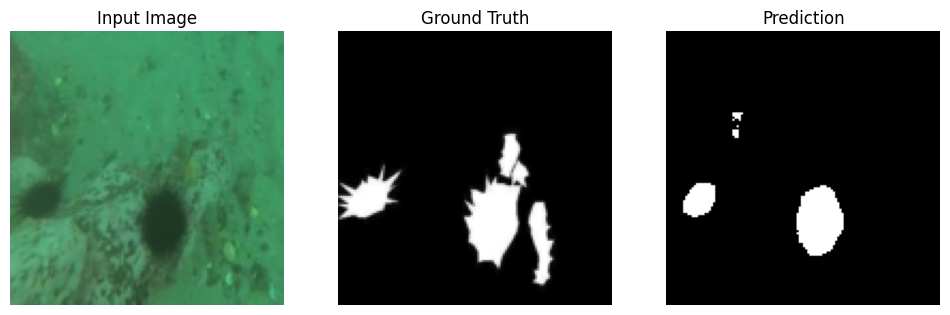

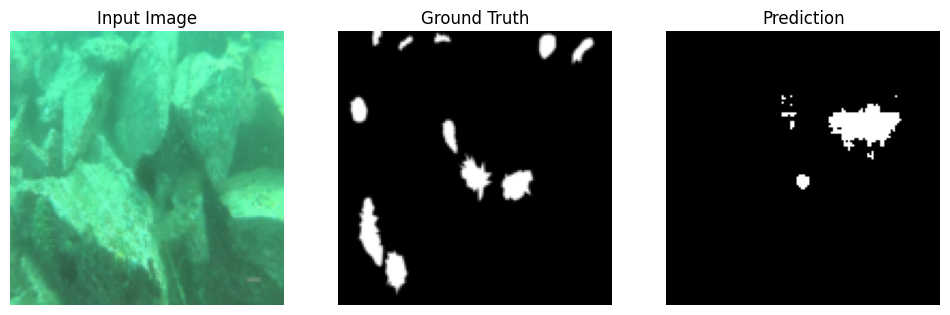

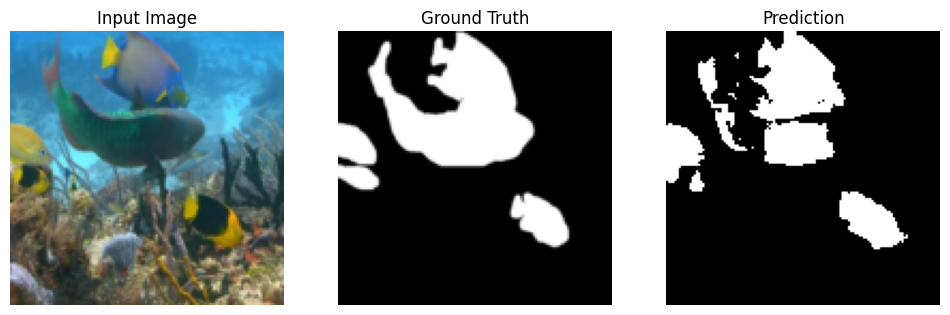

In [16]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    for idx, (img, mask) in enumerate(test_loader):
        img = img.to(device)
        pred = model(img).cpu().squeeze().numpy()
        img = img.cpu().squeeze().permute(1, 2, 0).numpy()
        mask = mask.squeeze().numpy()

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(img)
        plt.title("Input Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(mask, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pred > 0.5, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")
        plt.show()

        if idx == 2:
            break  # Show only first 3 samples

In [17]:
# Install torchinfo
!pip install torchinfo > /dev/null

In [20]:
from torchinfo import summary

summary(model, input_size=(1, 3, 128, 128))

Layer (type:depth-idx)                   Output Shape              Param #
AER_UNet                                 [1, 1, 128, 128]          --
├─ResidualBlock: 1-1                     [1, 32, 128, 128]         --
│    └─Conv2d: 2-1                       [1, 32, 128, 128]         128
│    └─Conv2d: 2-2                       [1, 32, 128, 128]         896
│    └─BatchNorm2d: 2-3                  [1, 32, 128, 128]         64
│    └─ReLU: 2-4                         [1, 32, 128, 128]         --
│    └─Conv2d: 2-5                       [1, 32, 128, 128]         9,248
│    └─BatchNorm2d: 2-6                  [1, 32, 128, 128]         64
│    └─ReLU: 2-7                         [1, 32, 128, 128]         --
├─MaxPool2d: 1-2                         [1, 32, 64, 64]           --
├─ResidualBlock: 1-3                     [1, 64, 64, 64]           --
│    └─Conv2d: 2-8                       [1, 64, 64, 64]           2,112
│    └─Conv2d: 2-9                       [1, 64, 64, 64]           18,496
│  

In [26]:
len(train_loader)*8

2520

In [27]:
len(test_loader)

500